 ## Lending Club Loan Default Prediction

### Problem Statement
Predict whether a loan applicant will default or fully repay their loan,
using only information available at the time of loan approval.

### Business Context
A lender needs to assess risk *before* approving a loan not after.
This model simulates that decision point.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')  # keeps output clean from harmless sklearn/pandas warnings

In [3]:
# Loading Data

df = pd.read_csv('/Users/nashasaledz/Desktop/DS online/Lending_Club_Loan_Data_030926/archive/accepted_2007_to_2018q4.csv.gz', compression='gzip', low_memory=False)
print(df.shape)

(2260701, 151)


In [5]:
df.head(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Checking the cloumns

for col in df.columns:
    print(col)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
fico_range_low
fico_range_high
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
last_fico_range_high
last_fico_range_low
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
to

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [11]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [13]:
# Keep only loans with a known, final outcome
finished_statuses = [
    'Fully Paid', 'Charged Off',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off',
    'Default'
]

df = df[df['loan_status'].isin(finished_statuses)].copy()

# Turn it into a simple yes/no answer: 1 = defaulted, 0 = paid back fine
bad_loan = ['Charged Off', 'Does not meet the credit policy. Status:Charged Off', 'Default']
df['target'] = df['loan_status'].isin(bad_loan).astype(int)

print(df.shape)
print(df['target'].value_counts(normalize=True))

(1348099, 152)
target
0    0.800193
1    0.199807
Name: proportion, dtype: float64


In [15]:
leakage_cols = [
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    'hardship_flag', 'payment_plan_start_date',
    'out_prncp', 'out_prncp_inv'
]
print(leakage_cols)

['total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term', 'hardship_flag', 'payment_plan_start_date', 'out_prncp', 'out_prncp_inv']


In [17]:
leakage_cols = [c for c in leakage_cols if c in df.columns]

In [19]:
df = df.drop(columns=leakage_cols)
print(f"Dropped {len(leakage_cols)} leakage columns. Remaining: {df.shape[1]} columns")
df.head(5)

Dropped 24 leakage columns. Remaining: 128 columns


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_start_date,hardship_end_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,target
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0


In [21]:
null_frac = df.isnull().mean()
high_null_cols = null_frac[null_frac > 0.90].index.tolist()

df = df.drop(columns=high_null_cols)
print(f"Dropped {len(high_null_cols)} mostly-empty columns. Remaining: {df.shape[1]} columns")

Dropped 31 mostly-empty columns. Remaining: 97 columns


In [23]:
# Checking dropped columns & missing value percentage

null_frac[high_null_cols].sort_values(ascending=False)

member_id                                     1.000000
orig_projected_additional_accrued_interest    0.997210
hardship_type                                 0.995730
hardship_payoff_balance_amount                0.995730
hardship_loan_status                          0.995730
hardship_dpd                                  0.995730
hardship_length                               0.995730
hardship_end_date                             0.995730
hardship_start_date                           0.995730
hardship_amount                               0.995730
deferral_term                                 0.995730
hardship_status                               0.995730
hardship_reason                               0.995730
hardship_last_payment_amount                  0.995730
sec_app_mths_since_last_major_derog           0.995068
sec_app_revol_util                            0.986419
revol_bal_joint                               0.986177
sec_app_num_rev_accts                         0.986176
sec_app_ea

In [27]:
# Check the raw, messy values in a few suspicious columns before fixing them
for col in ['term', 'emp_length']:
    print(col, '->', df[col].dtype)
    print(df[col].unique())
    print()

term -> object
[' 36 months' ' 60 months']

emp_length -> object
['10+ years' '3 years' '4 years' '6 years' '7 years' '8 years' '2 years'
 '5 years' '9 years' '< 1 year' '1 year' nan]



In [29]:
# term is stored as text like " 36 months" — removing word like  "months" and converting to a number
df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)

print(df['term'].unique())  # confirm it's now just [36, 60] as numbers

[36 60]


In [31]:
# Changing emp_length from < 1 year to 0, 5 years to 5, 10 year + to 10 etc
emp_length_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

df['emp_length'] = df['emp_length'].map(emp_length_map)

print(df['emp_length'].value_counts(dropna=False))

emp_length
10.0    442679
2.0     122100
0.0     108537
3.0     107868
1.0      88843
5.0      84326
4.0      80763
NaN      78550
6.0      62879
8.0      60811
7.0      59724
9.0      51019
Name: count, dtype: int64


In [33]:
# Convert both date columns from text into real date objects
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')

print(df[['issue_d', 'earliest_cr_line']].head())

     issue_d earliest_cr_line
0 2015-12-01       2003-08-01
1 2015-12-01       1999-12-01
2 2015-12-01       2000-08-01
4 2015-12-01       1998-06-01
5 2015-12-01       1987-10-01


In [37]:
# Calculate the gap between them, in months
df['credit_history_months'] = (
    (df['issue_d'].dt.year - df['earliest_cr_line'].dt.year) * 12 +
    (df['issue_d'].dt.month - df['earliest_cr_line'].dt.month)
)

print(df['credit_history_months'].describe())

count    1.348070e+06
mean     1.950060e+02
std      9.009716e+01
min      6.000000e+00
25%      1.340000e+02
50%      1.770000e+02
75%      2.400000e+02
max      9.990000e+02
Name: credit_history_months, dtype: float64


In [39]:
# Now that we've extracted the useful info, drop the raw date columns
df = df.drop(columns=['issue_d', 'earliest_cr_line'])
print(df.shape)

(1348099, 96)


In [41]:
# Row with too long "credit history" (over 50 years)
print((df['credit_history_months'] > 600).sum())

# Rowsended  with no value at all after the date 
print(df['credit_history_months'].isnull().sum())

1248
29


In [43]:
# Cap unrealistic values at 600 months (50 years) w/o deleting them
df['credit_history_months'] = df['credit_history_months'].clip(upper=600)

print(df['credit_history_months'].describe())

count    1.348070e+06
mean     1.949681e+02
std      8.990900e+01
min      6.000000e+00
25%      1.340000e+02
50%      1.770000e+02
75%      2.400000e+02
max      6.000000e+02
Name: credit_history_months, dtype: float64


In [45]:
# Check what text-based (object) columns 
print(df.select_dtypes(include='object').columns.tolist())

['id', 'grade', 'sub_grade', 'emp_title', 'home_ownership', 'verification_status', 'loan_status', 'pymnt_plan', 'url', 'purpose', 'title', 'zip_code', 'addr_state', 'initial_list_status', 'application_type', 'disbursement_method']


In [47]:
for col in ['pymnt_plan', 'initial_list_status', 'application_type', 'disbursement_method']:
    print(col, '->', df[col].value_counts(dropna=False).to_dict())
    print()

pymnt_plan -> {'n': 1348099}

initial_list_status -> {'w': 784041, 'f': 564058}

application_type -> {'Individual': 1322293, 'Joint App': 25806}

disbursement_method -> {'Cash': 1341199, 'DirectPay': 6900}



In [49]:
# Dropping unnecessary columns
drop_cols = ['id', 'url', 'emp_title', 'title', 'zip_code', 'loan_status', 'pymnt_plan']
df = df.drop(columns=drop_cols)
print(df.shape)

(1348099, 89)


In [51]:
# Renaming A -> G, to A=0, B=1, etc...
grade_map = {g: i for i, g in enumerate(sorted(df['grade'].unique()))}
df['grade'] = df['grade'].map(grade_map)

# sub_grade goes A1 -> G5, same idea but more fine-grained
sub_grade_order = sorted(df['sub_grade'].unique())
sub_grade_map = {g: i for i, g in enumerate(sub_grade_order)}
df['sub_grade'] = df['sub_grade'].map(sub_grade_map)

print(df[['grade', 'sub_grade']].head())

   grade  sub_grade
0      2         13
1      2         10
2      1          8
4      5         25
5      2         12


In [53]:
# One hot encoding yes/no column
nominal_cols = ['home_ownership', 'verification_status', 'purpose', 'addr_state',
                 'initial_list_status', 'application_type', 'disbursement_method']

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print(df.shape)

(1348099, 155)


In [55]:
# Spliting to train & test 

# X = everything we'll use to predict; y = the answer we're trying to predict
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(1078479, 154) (269620, 154)
0.19980732123666756 0.19980713596914176


In [57]:
# Handling missing values before modelling
missing_pct = (X_train.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct)

mths_since_last_record            83.012187
mths_since_recent_bc_dlq          76.321004
mths_since_last_major_derog       73.735974
mths_since_recent_revol_delinq    66.609364
il_util                           65.482684
                                    ...    
delinq_amnt                        0.002225
pub_rec                            0.002225
total_acc                          0.002225
acc_now_delinq                     0.002225
annual_inc                         0.000371
Length: 69, dtype: float64


In [59]:
# Group 1: High-missing columns where NaN likely means "this never happened"
# To fill with 0, since these are "count" or "months since" style columns where
# 0 reasonably represents "no such event on record"
high_missing_cols = missing_pct[missing_pct > 50].index.tolist()

for col in high_missing_cols:
    X_train[col] = X_train[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

# Group 2 & 3: All missing values gets filled with the median
# (median is safer than mean here since it's less thrown off by extreme outliers)
remaining_missing_cols = missing_pct[missing_pct <= 50].index.tolist()

for col in remaining_missing_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

print(X_train.isnull().sum().sum())  
print(X_test.isnull().sum().sum())

0
0


In [61]:
# Logistic Regression Model

# class_weight='balanced' tells the model to pay extra attention to the minority class (defaults),
# since we know from Step 3 that only ~20% of loans are defaults
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [63]:
# LR prediction
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# ROC-AUC: how well the model separates "will default" from "won't default"
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {auc_score:.4f}")

# precision, recall, f1-score broken down by class
print(classification_report(y_test, y_pred))

# confusion matrix: actual counts of right/wrong predictions
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.6494
              precision    recall  f1-score   support

           0       0.86      0.61      0.72    215748
           1       0.28      0.61      0.38     53872

    accuracy                           0.61    269620
   macro avg       0.57      0.61      0.55    269620
weighted avg       0.75      0.61      0.65    269620

[[132514  83234]
 [ 21278  32594]]


In [65]:
# Scale_pos_weight does for XGBoost what class_weight='balanced' did for Logistic Regression —

scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42
)

xgb_model.fit(X_train, y_train)
print("XGBoost trained successfully")

XGBoost trained successfully


In [67]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

auc_score_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"XGBoost ROC-AUC: {auc_score_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost ROC-AUC: 0.7350
              precision    recall  f1-score   support

           0       0.89      0.66      0.76    215748
           1       0.33      0.68      0.45     53872

    accuracy                           0.67    269620
   macro avg       0.61      0.67      0.60    269620
weighted avg       0.78      0.67      0.70    269620

[[142807  72941]
 [ 17219  36653]]


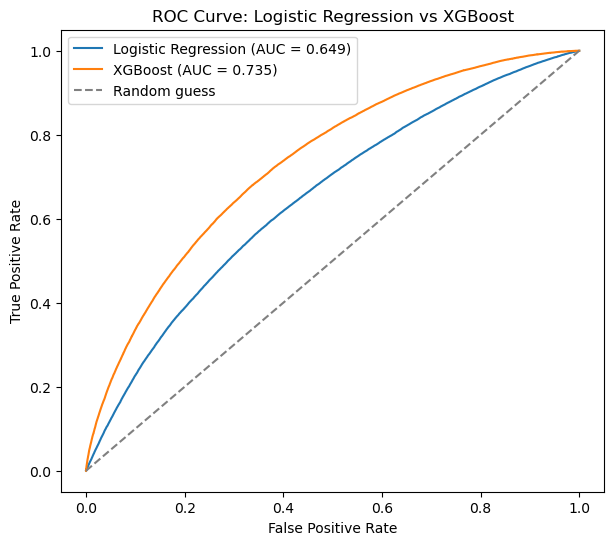

In [69]:
# Obtain false-positive-rate / true-positive-rate at every possible threshold
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_score_xgb:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression vs XGBoost')
plt.legend()
plt.show()

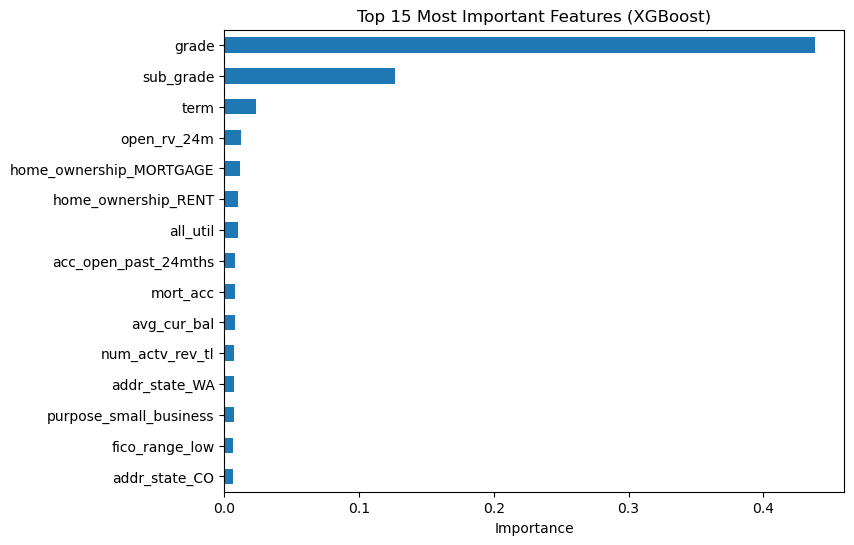

In [73]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top15.sort_values().plot(kind='barh')
plt.title('Top 15 Most Important Features (XGBoost)')
plt.xlabel('Importance')
plt.show()

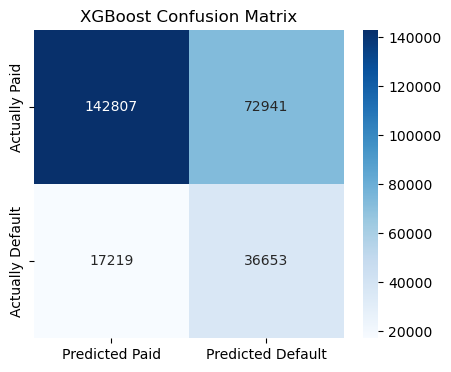

In [75]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Paid', 'Predicted Default'],
            yticklabels=['Actually Paid', 'Actually Default'])
plt.title('XGBoost Confusion Matrix')
plt.show()

In [77]:
# Exploring options to drop grade and sub_grade from both train and test sets 
X_train_nogr = X_train.drop(columns=['grade', 'sub_grade'])
X_test_nogr = X_test.drop(columns=['grade', 'sub_grade'])

xgb_model_nogr = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42
)

xgb_model_nogr.fit(X_train_nogr, y_train)

y_pred_nogr = xgb_model_nogr.predict(X_test_nogr)
y_pred_proba_nogr = xgb_model_nogr.predict_proba(X_test_nogr)[:, 1]

auc_score_nogr = roc_auc_score(y_test, y_pred_proba_nogr)
print(f"XGBoost (no grade) ROC-AUC: {auc_score_nogr:.4f}")
print(classification_report(y_test, y_pred_nogr))

XGBoost (no grade) ROC-AUC: 0.7335
              precision    recall  f1-score   support

           0       0.89      0.66      0.76    215748
           1       0.33      0.68      0.45     53872

    accuracy                           0.67    269620
   macro avg       0.61      0.67      0.60    269620
weighted avg       0.78      0.67      0.70    269620



### Conclusion

This project builds a binary classifier to predict loan default risk at the
point of loan origination, using the Lending Club accepted-loans dataset
(~1.35M resolved loans after filtering out in-progress loans).

**Approach:**
- Defined the target as Fully Paid (0) vs Charged Off/Default (1)
- Removed all post-origination "leakage" columns (payment history, recoveries,
  settlement data) to ensure the model only uses information available at
  approval time
- Cleaned and engineered features (e.g. credit_history_months from raw dates,
  ordinal encoding for grade/emp_length, one-hot encoding for nominal categories)
- Compared a Logistic Regression baseline against XGBoost

**Results:**
- Logistic Regression: ROC-AUC 0.649
- XGBoost: ROC-AUC 0.735 — a meaningful improvement, consistent with XGBoost's
  ability to capture non-linear relationships in tabular data

**Follow-up experiment — does the model just rely on Lending Club's own grade?**
Feature importance showed grade/sub-grade as by far the strongest predictors,
raising the question of whether the model was simply learning to replicate
Lending Club's existing risk assessment rather than deriving risk independently.
Retraining without grade and sub-grade produced almost identical performance
(ROC-AUC 0.7335 vs 0.7350)suggesting the model isn't dependent on the lender's
grade specifically, but is able to reconstruct an equivalent risk signal directly
from the underlying borrower attributes (income, credit history, DTI, etc.) that
the grade itself is likely derived from.

**Business implication:** this model could plausibly be used even in contexts
where a formal grade isn't available, or as an independent check against an
existing grading system.

**Limitations:** the model still has a fairly high false-positive rate (many
safe loans flagged as risky) a deliberate trade-off from prioritizing catching
actual defaults (recall), which would need to be tuned based on a lender's actual
cost tolerance for false alarms vs missed defaults.

In [82]:
#Build a clean, dashboard-ready dataset

dashboard_df = df.loc[X_test.index].copy()

# Adding the model's predictions 
dashboard_df['predicted_default_prob'] = y_pred_proba_xgb
dashboard_df['predicted_default'] = y_pred_xgb

# Creating a simple risk tier for easy filtering/visuals in Power BI
dashboard_df['risk_tier'] = pd.cut(
    dashboard_df['predicted_default_prob'],
    bins=[0, 0.2, 0.5, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print(dashboard_df.shape)
dashboard_df.head()

(269620, 158)


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,...,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY,initial_list_status_w,application_type_Joint App,disbursement_method_DirectPay,predicted_default_prob,predicted_default,risk_tier
179613,32000.0,32000.0,31850.0,36,13.99,1093.53,2,13,6.0,130000.0,...,False,False,False,False,False,False,False,0.560862,1,High Risk
190815,6000.0,6000.0,6000.0,36,10.99,196.41,1,8,10.0,51596.0,...,False,False,False,False,True,False,False,0.364283,0,Medium Risk
1929503,29100.0,29100.0,29075.0,60,13.11,663.76,1,8,10.0,60000.0,...,False,False,False,False,False,False,False,0.561993,1,High Risk
121989,14000.0,14000.0,14000.0,36,7.26,433.95,0,3,5.0,65850.0,...,False,False,False,False,True,False,False,0.195196,0,Low Risk
304242,5050.0,5050.0,5050.0,36,10.99,165.31,1,8,10.0,162000.0,...,False,False,False,False,True,False,False,0.337461,0,Medium Risk


In [86]:
def undo_onehot(X, prefix):
    # grab every dummy column that starts with this prefix (e.g. all 'purpose_...' columns)
    cols = [c for c in X.columns if c.startswith(prefix + '_')]
    # for each row, find which dummy column is True, and strip the prefix to recover the original label
    result = X[cols].idxmax(axis=1).str.replace(prefix + '_', '', regex=False)
    # rows where ALL dummy columns are False belong to the category that got dropped
    # (remember drop_first=True in Step 8 — one category per group has no dummy column at all)
    all_false = ~X[cols].any(axis=1)
    return result, all_false

purpose_vals, purpose_dropped = undo_onehot(X_test, 'purpose')
home_vals, home_dropped = undo_onehot(X_test, 'home_ownership')
addr_vals, addr_dropped = undo_onehot(X_test, 'addr_state')
verif_vals, verif_dropped = undo_onehot(X_test, 'verification_status')

print(purpose_vals.value_counts())
print(purpose_dropped.sum())  # how many rows belong to the "dropped" category

debt_consolidation    156553
credit_card            62069
home_improvement       17341
other                  15628
major_purchase          5972
medical                 3099
small_business          3022
moving                  1908
vacation                1817
house                   1479
wedding                  455
renewable_energy         206
educational               71
Name: count, dtype: int64
2900


In [88]:
dashboard_cols = [
    # loan details
    'loan_amnt', 'int_rate', 'term', 'installment', 'purpose',
    # borrower profile
    'annual_inc', 'emp_length', 'home_ownership', 'dti', 'addr_state',
    'verification_status', 'fico_range_low', 'fico_range_high',
    'credit_history_months', 'grade', 'sub_grade',
    # outcome + model output
    'target', 'predicted_default_prob', 'predicted_default', 'risk_tier'
]

dashboard_df = dashboard_df[dashboard_cols]
print(dashboard_df.shape)
dashboard_df.head()

KeyError: "['purpose', 'home_ownership', 'addr_state', 'verification_status'] not in index"

In [98]:
def undo_onehot(X, prefix):
    # grab every dummy column that starts with this prefix (e.g. all 'purpose_...' columns)
    cols = [c for c in X.columns if c.startswith(prefix + '_')]
    # for each row, find which dummy column is True, and strip the prefix to recover the original label
    result = X[cols].idxmax(axis=1).str.replace(prefix + '_', '', regex=False)
    # rows where ALL dummy columns are False belong to the category that got dropped
    # (remember drop_first=True in Step 8 — one category per group has no dummy column at all)
    all_false = ~X[cols].any(axis=1)
    return result, all_false

purpose_vals, purpose_dropped = undo_onehot(X_test, 'purpose')
home_vals, home_dropped = undo_onehot(X_test, 'home_ownership')
addr_vals, addr_dropped = undo_onehot(X_test, 'addr_state')
verif_vals, verif_dropped = undo_onehot(X_test, 'verification_status')

print(purpose_vals.value_counts())
print(purpose_dropped.sum())  # how many rows belong to the "dropped" category

debt_consolidation    156553
credit_card            62069
home_improvement       17341
other                  15628
major_purchase          5972
medical                 3099
small_business          3022
moving                  1908
vacation                1817
house                   1479
wedding                  455
renewable_energy         206
educational               71
Name: count, dtype: int64
2900


In [96]:
dashboard_df.to_csv('lending_club_dashboard_data.csv', index=False)
print("Exported successfully")

import os
print(os.path.abspath('lending_club_dashboard_data.csv'))

Exported successfully
/Users/nashasaledz/Desktop/DS online/Lending_Club_Loan_Data_030926/lending_club_dashboard_data.csv
